<a href="https://colab.research.google.com/github/Enock-Yegon/Introduction-to-Python/blob/main/day2wk4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('football_epl.csv') # 1. Load dataset
df

,Date,Home Team,Away Team,Score,Stadium,Attendance,Referee
0,17 Dec 2024,NEWCASTLE,Liverpool,2-0,Etihad,NaN,C. Kavanagh
1,5 Aug 2024,Aston Villa,Man Utd,4-4,Villa Park,64133,NaN
2,01/10/2024,Newcastle,West Ham United,1-0,Tottenham Stadium,42090,M. Oliver
3,2022-09-22,west ham,LIVERPOOL,NaN,London Stadium,71986,P. Tierney
4,2023-09-08,Aston Villa,Tottenham Hotspur,NaN,Old Trafford,52851,P. Tierney
...,...,...,...,...,...,...,...
2555,2024-11-10,Tottenham,Chelsea FC,2-1,NaN,NaN,C. Kavanagh
2556,23/10/2024,MAN CITY,liverpool,1-0,Goodison Park,"31,247",NaN
2557,23/09/2022,Spurs,liverpool,0-1,Emirates,"38,937",P. Tierney
2558,2022-10-07,Tottenham Hotspur,Man Utd,2-0,NaN,"69,359",M. Dean


Step 1: Data Inspection

*   Goal: Inspect shape, column data types, missing values, and high-level statistical summaries.




In [ ]:
df.head() # check the first few colums


,Date,Home Team,Away Team,Score,Stadium,Attendance,Referee
0,17 Dec 2024,NEWCASTLE,Liverpool,2-0,Etihad,NaN,C. Kavanagh
1,5 Aug 2024,Aston Villa,Man Utd,4-4,Villa Park,64133,NaN
2,01/10/2024,Newcastle,West Ham United,1-0,Tottenham Stadium,42090,M. Oliver
3,2022-09-22,west ham,LIVERPOOL,NaN,London Stadium,71986,P. Tierney
4,2023-09-08,Aston Villa,Tottenham Hotspur,NaN,Old Trafford,52851,P. Tierney


In [ ]:
df.info() # 3. Check shape, column names, data types, and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2560 entries, 0 to 2559
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        2560 non-null   object
 1   Home Team   2560 non-null   object
 2   Away Team   2560 non-null   object
 3   Score       2426 non-null   object
 4   Stadium     2340 non-null   object
 5   Attendance  2056 non-null   object
 6   Referee     2172 non-null   object
dtypes: object(7)
memory usage: 140.1+ KB


In [ ]:
df.describe() # 6. View summary statistics for numerical columns

,Date,Home Team,Away Team,Score,Stadium,Attendance,Referee
count,2560,2560,2560,2426,2340,2056,2172
unique,1040,40,40,65,10,1988,5
top,17/11/2023,Man. City,everton,1-1,Tottenham Stadium,"32,381",M. Dean
freq,10,86,93,255,261,3,458


In [ ]:
df.tail() #check the last few rows

,Date,Home Team,Away Team,Score,Stadium,Attendance,Referee
2555,2024-11-10,Tottenham,Chelsea FC,2-1,NaN,NaN,C. Kavanagh
2556,23/10/2024,MAN CITY,liverpool,1-0,Goodison Park,"31,247",NaN
2557,23/09/2022,Spurs,liverpool,0-1,Emirates,"38,937",P. Tierney
2558,2022-10-07,Tottenham Hotspur,Man Utd,2-0,NaN,"69,359",M. Dean
2559,24/12/2023,Liverpool FC,Man. United,1-2,Villa Park,"37,102",A. Taylor


In [ ]:
df.isna().sum() # 4. Check for missing values

,0
Date,0
Home Team,0
Away Team,0
Score,134
Stadium,220
Attendance,504
Referee,388


In [ ]:
df.duplicated().sum() # 5. Check duplicate rows

np.int64(60)

Step 2: Data Cleaning


*  Goal: Fix text casing, strip trailing spaces, remove duplicates, and handle missing values.




In [49]:
import pandas as pd
import numpy as np

# 1. Load the raw dataset
df = pd.read_csv("football_epl.csv")

# 2. Standardize Team Names
team_mapping = {
    'newcastle': 'Newcastle United', 'newcastle united': 'Newcastle United', 'newcastle utd': 'Newcastle United',
    'aston villa': 'Aston Villa', 'villa': 'Aston Villa',
    'west ham': 'West Ham United', 'west ham united': 'West Ham United',
    'liverpool': 'Liverpool', 'liverpool fc': 'Liverpool',
    'man. city': 'Manchester City', 'man city': 'Manchester City',
    'man utd': 'Manchester United', 'man united': 'Manchester United', 'man. united': 'Manchester United', 'manchester united': 'Manchester United',
    'everton': 'Everton', 'arsenal': 'Arsenal',
    'tottenham': 'Tottenham Hotspur', 'tottenham hotspur': 'Tottenham Hotspur', 'spurs': 'Tottenham Hotspur',
    'chelsea fc': 'Chelsea'
}

df['Home Team'] = df['Home Team'].str.strip().str.lower().map(lambda x: team_mapping.get(x, x.title()))
df['Away Team'] = df['Away Team'].str.strip().str.lower().map(lambda x: team_mapping.get(x, x.title()))

# 3. Parse Dates
df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')

# 4. Clean Attendance
df['Attendance'] = df['Attendance'].astype(str).str.replace(',', '').str.strip()
df['Attendance'] = pd.to_numeric(df['Attendance'], errors='coerce')

# 5. Extract Goals & Match Outcomes
score_clean = df['Score'].str.replace(' ', '')
score_split = score_clean.str.split('-', expand=True)

df['Home_Goals'] = pd.to_numeric(score_split[0], errors='coerce')
df['Away_Goals'] = pd.to_numeric(score_split[1], errors='coerce')
df['Total_Goals'] = df['Home_Goals'] + df['Away_Goals']

def get_result(row):
    if pd.isna(row['Home_Goals']) or pd.isna(row['Away_Goals']):
        return np.nan
    if row['Home_Goals'] > row['Away_Goals']:
        return 'Home Win'
    elif row['Home_Goals'] < row['Away_Goals']:
        return 'Away Win'
    else:
        return 'Draw'

df['Result'] = df.apply(get_result, axis=1)

# 6. Save as Excel file (.xlsx)
df.to_excel("cleaned_football_epl.xlsx", index=False, engine="openpyxl")

print("File successfully saved as 'cleaned_football_epl.xlsx'")
df_clean = pd.read_excel('cleaned_football_epl.xlsx')
df_clean.head()


File successfully saved as 'cleaned_football_epl.xlsx'


,Date,Home Team,Away Team,Score,Stadium,Attendance,Referee,Home_Goals,Away_Goals,Total_Goals,Result
0,2024-12-17,Newcastle United,Liverpool,2-0,Etihad,NaN,C. Kavanagh,2.0,0.0,2.0,Home Win
1,2024-08-05,Aston Villa,Manchester United,4-4,Villa Park,64133.0,NaN,4.0,4.0,8.0,Draw
2,2024-01-10,Newcastle United,West Ham United,1-0,Tottenham Stadium,42090.0,M. Oliver,1.0,0.0,1.0,Home Win
3,2022-09-22,West Ham United,Liverpool,NaN,London Stadium,71986.0,P. Tierney,NaN,NaN,NaN,NaN
4,2023-09-08,Aston Villa,Tottenham Hotspur,NaN,Old Trafford,52851.0,P. Tierney,NaN,NaN,NaN,NaN


Step 3: Filtering & Selection


* Isolate specific slices of interest—such as high-scoring encounters, specific stadium records, or matches involving specific teams.



In [45]:
# Filter 1: High-scoring matches (5 or more total goals)
high_scoring = df_clean[df_clean['Total_Goals'] >= 5]

# Filter 2: Specific team matches (e.g., Arsenal home matches)
arsenal_home = df_clean[df_clean['Home Team'] == 'Arsenal']

# Filter 3: Multi-condition filter (Home Wins with Attendance > 60,000)
large_crowd_home_wins = df_clean[(df_clean['Result'] == 'Home Win') & (df_clean['Attendance'] > 60000)]

# Select key columns
match_summaries = df_clean[['Date', 'Home Team', 'Away Team', 'Home_Goals', 'Away_Goals', 'Result']]
high_scoring.head()

,Date,Home Team,Away Team,Score,Stadium,Attendance,Referee,Home_Goals,Away_Goals,Total_Goals,Result
1,2024-08-05,Aston Villa,Manchester United,4-4,Villa Park,64133.0,NaN,4.0,4.0,8.0,Draw
12,2024-08-16,Liverpool,Everton,2-4,Goodison Park,62799.0,M. Dean,2.0,4.0,6.0,Away Win
15,2024-10-21,Aston Villa,Arsenal,3-3,London Stadium,61508.0,M. Dean,3.0,3.0,6.0,Draw
24,2023-11-17,Manchester United,West Ham United,4-1,NaN,32739.0,A. Taylor,4.0,1.0,5.0,Home Win
33,2022-10-31,Manchester City,Newcastle United,5-2,St James' Park,48088.0,C. Kavanagh,5.0,2.0,7.0,Home Win


In [53]:
arsenal_home.head(20)

,Date,Home Team,Away Team,Score,Stadium,Attendance,Referee,Home_Goals,Away_Goals,Total_Goals,Result
21,2022-10-13,Arsenal,Manchester United,0-1,Anfield,50889.0,P. Tierney,0.0,1.0,1.0,Away Win
22,2023-10-23,Arsenal,West Ham United,NaN,NaN,49818.0,A. Taylor,NaN,NaN,NaN,NaN
30,2023-01-08,Arsenal,Chelsea,2-0,Etihad,45616.0,C. Kavanagh,2.0,0.0,2.0,Home Win
65,2024-06-10,Arsenal,Tottenham Hotspur,1-3,Villa Park,59904.0,M. Dean,1.0,3.0,4.0,Away Win
74,2024-09-15,Arsenal,Newcastle United,1-0,Old Trafford,36467.0,M. Dean,1.0,0.0,1.0,Home Win
85,2022-08-13,Arsenal,Chelsea,1-1,NaN,45925.0,M. Dean,1.0,1.0,2.0,Draw
93,2024-11-29,Arsenal,Tottenham Hotspur,1-2,Villa Park,67456.0,C. Kavanagh,1.0,2.0,3.0,Away Win
103,2023-09-27,Arsenal,Chelsea,2-2,Old Trafford,69290.0,M. Oliver,2.0,2.0,4.0,Draw
107,2022-08-10,Arsenal,Tottenham Hotspur,1 - 2,Goodison Park,38080.0,P. Tierney,1.0,2.0,3.0,Away Win
109,2023-10-30,Arsenal,Aston Villa,3-4,Tottenham Stadium,45707.0,C. Kavanagh,3.0,4.0,7.0,Away Win


In [54]:
large_crowd_home_wins.head(20)

,Date,Home Team,Away Team,Score,Stadium,Attendance,Referee,Home_Goals,Away_Goals,Total_Goals,Result
27,2023-09-24,Newcastle United,Manchester United,2-0,Tottenham Stadium,63928.0,P. Tierney,2.0,0.0,2.0,Home Win
32,2024-12-20,Manchester United,Tottenham Hotspur,1-0,Emirates,71079.0,NaN,1.0,0.0,1.0,Home Win
39,2024-09-26,Liverpool,Manchester City,3-2,Anfield,69275.0,C. Kavanagh,3.0,2.0,5.0,Home Win
75,2022-11-28,Liverpool,Arsenal,3-1,Villa Park,65371.0,A. Taylor,3.0,1.0,4.0,Home Win
86,2022-08-19,Everton,Tottenham Hotspur,5-0,Etihad,63530.0,P. Tierney,5.0,0.0,5.0,Home Win
112,2023-09-13,Aston Villa,Tottenham Hotspur,1-0,NaN,61173.0,P. Tierney,1.0,0.0,1.0,Home Win
118,2024-11-24,Aston Villa,Chelsea,3-0,Goodison Park,67112.0,M. Oliver,3.0,0.0,3.0,Home Win
121,2023-09-11,Liverpool,Manchester United,2 - 1,Goodison Park,66920.0,C. Kavanagh,2.0,1.0,3.0,Home Win
131,2022-06-08,Chelsea,Everton,4-2,Goodison Park,71696.0,P. Tierney,4.0,2.0,6.0,Home Win
146,2022-11-27,Everton,Aston Villa,1-0,Etihad,60432.0,M. Oliver,1.0,0.0,1.0,Home Win


In [55]:
match_summaries.head(20)

,Date,Home Team,Away Team,Home_Goals,Away_Goals,Result
0,2024-12-17,Newcastle United,Liverpool,2.0,0.0,Home Win
1,2024-08-05,Aston Villa,Manchester United,4.0,4.0,Draw
2,2024-01-10,Newcastle United,West Ham United,1.0,0.0,Home Win
3,2022-09-22,West Ham United,Liverpool,NaN,NaN,NaN
4,2023-09-08,Aston Villa,Tottenham Hotspur,NaN,NaN,NaN
5,2022-12-21,Aston Villa,Arsenal,0.0,1.0,Away Win
6,2022-09-08,Aston Villa,Liverpool,0.0,0.0,Draw
7,2022-09-22,Liverpool,Tottenham Hotspur,1.0,0.0,Home Win
8,2022-09-11,Aston Villa,Liverpool,0.0,0.0,Draw
9,2022-08-22,Manchester City,Liverpool,0.0,1.0,Away Win


Step 4: Pivot Tables



* Aggregate key statistics across multiple categorical dimensions using df.pivot_table().




In [ ]:
pivot_goals = df_clean.pivot_table(
    index='Home Team',
    values=['Home_Goals', 'Away_Goals', 'Total_Goals'],
    aggfunc='mean'
).round(2)
pivot_goals

,Away_Goals,Home_Goals,Total_Goals
Home Team,,,
Arsenal,1.23,1.40,2.63
Aston Villa,1.19,1.29,2.48
Chelsea,1.20,1.36,2.56
Everton,1.18,1.30,2.49
Liverpool,1.12,1.52,2.64
Manchester City,1.11,1.51,2.62
Manchester United,1.11,1.33,2.44
Newcastle United,1.06,1.30,2.37
Tottenham Hotspur,1.19,1.40,2.59


In [ ]:
pivot_stadiums = df_clean.pivot_table(
    index='Stadium',
    columns='Result',
    values='Date',
    aggfunc='count',
    fill_value=0
)
pivot_stadiums

Result,Away Win,Draw,Home Win
Stadium,,,
Anfield,60,38,83
Emirates,64,51,102
Etihad,63,56,103
Goodison Park,65,60,96
London Stadium,65,73,81
Old Trafford,69,58,79
St James' Park,53,68,87
Stamford Bridge,90,54,87
Tottenham Stadium,64,62,114


Step 5: Data

*  Visualization
Generate graphs to visualize match outcome distributions, goal spreads, and team performance metrics.




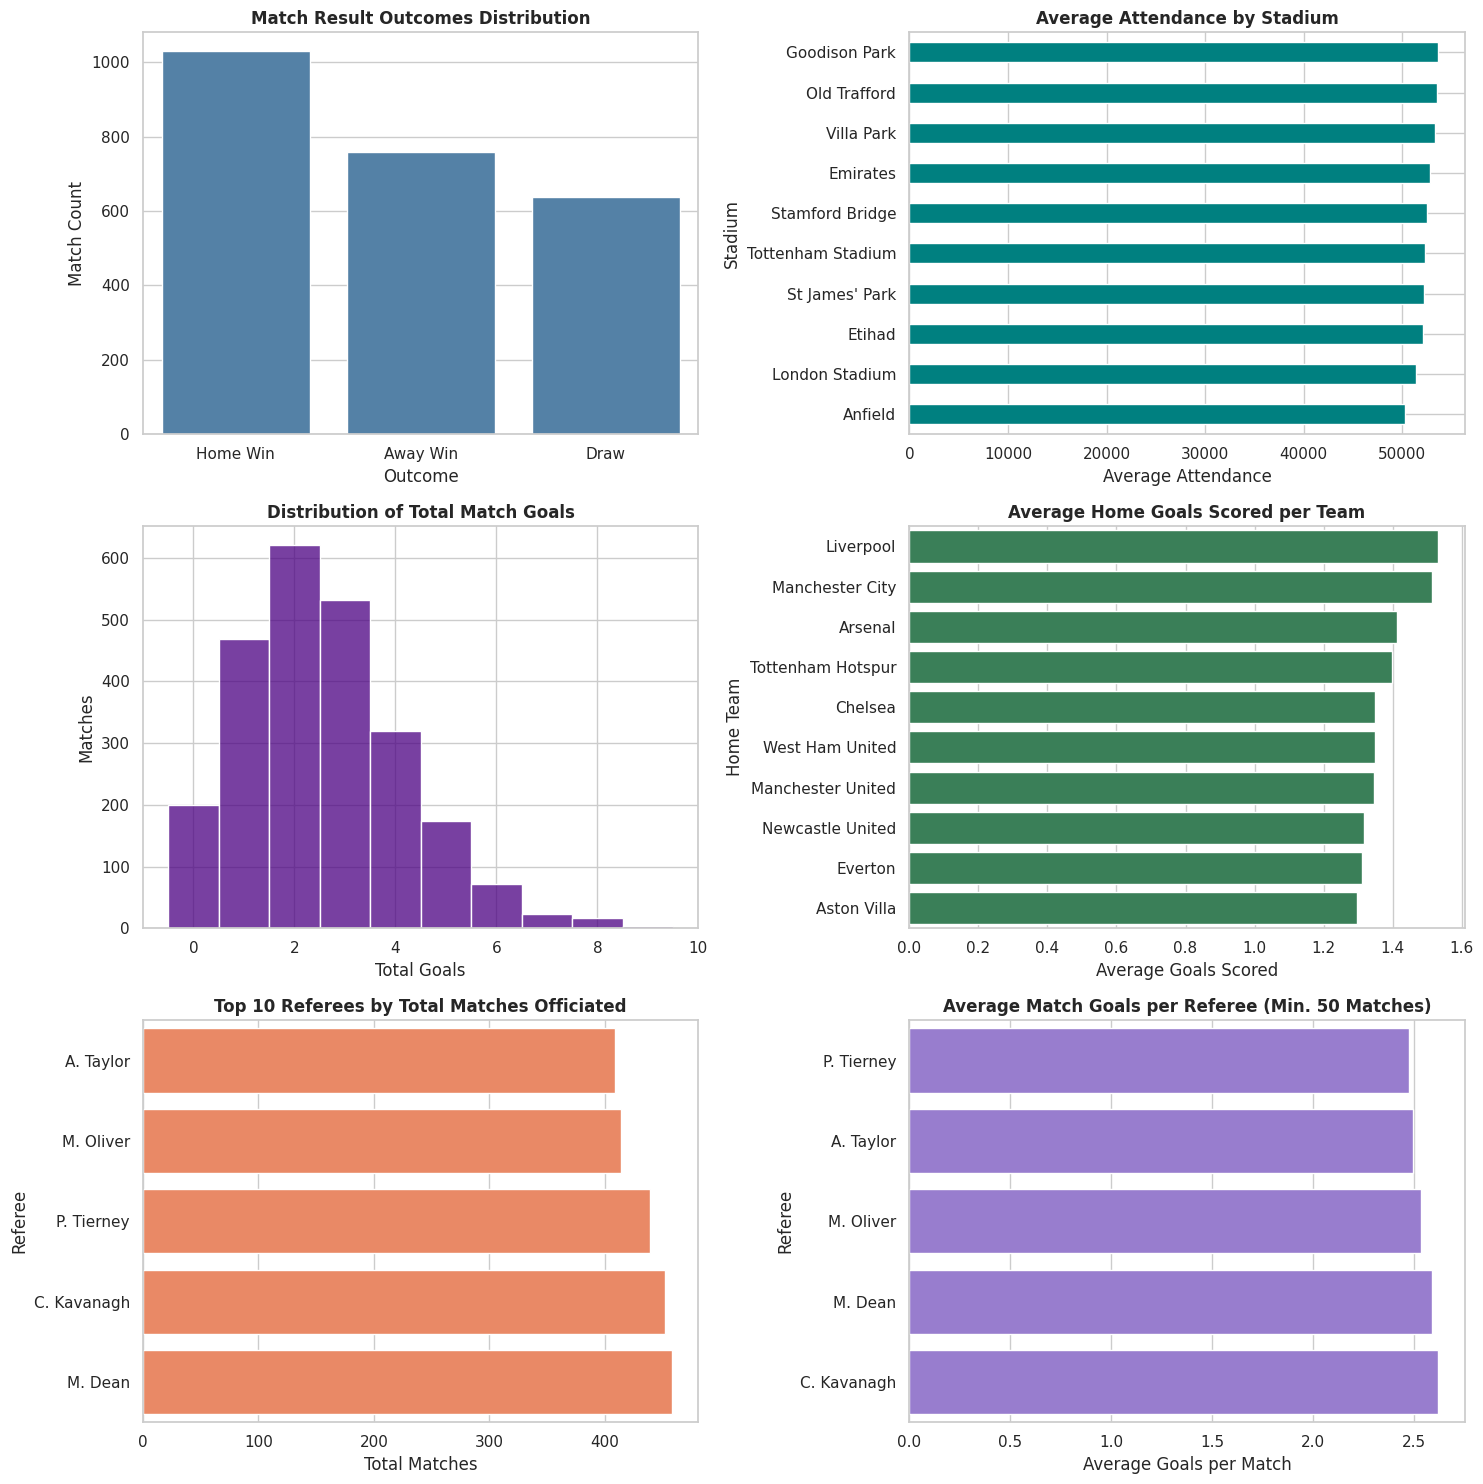

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# 1. Match Outcome Distribution
sns.countplot(
    data=df_clean,
    x='Result',
    ax=axes[0, 0],
    color='steelblue',
    order=['Home Win', 'Away Win', 'Draw']
)
axes[0, 0].set_title('Match Result Outcomes Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Outcome')
axes[0, 0].set_ylabel('Match Count')

# 2. Average Attendance by Stadium
avg_att = df_clean.groupby('Stadium')['Attendance'].mean().sort_values(ascending=True)
avg_att.plot(kind='barh', ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Average Attendance by Stadium', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Average Attendance')

# 3. Total Goals Distribution
sns.histplot(df_clean['Total_Goals'].dropna(), discrete=True, ax=axes[1, 0], color='indigo')
axes[1, 0].set_title('Distribution of Total Match Goals', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Total Goals')
axes[1, 0].set_ylabel('Matches')

# 4. Average Home Goals by Team
home_goals_avg = df_clean.groupby('Home Team')['Home_Goals'].mean().sort_values(ascending=False)
sns.barplot(x=home_goals_avg.values, y=home_goals_avg.index, ax=axes[1, 1], color='seagreen')
axes[1, 1].set_title('Average Home Goals Scored per Team', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Average Goals Scored')

# 5. Top 10 Referees by Matches Officiated
ref_counts = df_clean['Referee'].str.strip().value_counts().head(10).sort_values(ascending=True)
sns.barplot(x=ref_counts.values, y=ref_counts.index, ax=axes[2, 0], color='coral')
axes[2, 0].set_title('Top 10 Referees by Total Matches Officiated', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Total Matches')

# 6. Average Goals per Match by Active Referees (Min 50 Matches)
ref_metrics = df_clean.groupby('Referee').agg(
    Matches=('Result', 'count'),
    Avg_Goals=('Total_Goals', 'mean')
)
active_refs = ref_metrics[ref_metrics['Matches'] >= 50].sort_values(by='Avg_Goals', ascending=True)

sns.barplot(x=active_refs['Avg_Goals'].values, y=active_refs.index, ax=axes[2, 1], color='mediumpurple')
axes[2, 1].set_title('Average Match Goals per Referee (Min. 50 Matches)', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Average Goals per Match')

plt.tight_layout()
plt.show()